<h1>DENGUE ANALYTICS</h1>

<h1>Enriquez</h1>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
import calendar

In [2]:
den = pd.read_csv('datasets\\dengue.csv')

In [3]:
den

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0
3,April,2016,Region I,240,2
4,May,2016,Region I,243,1
...,...,...,...,...,...
1015,August,2020,BARMM,91,0
1016,September,2020,BARMM,16,8
1017,October,2020,BARMM,13,9
1018,November,2020,BARMM,15,1


In [4]:
den['Date'] = pd.to_datetime(den['Month'] + ' ' + den['Year'].astype(str), format='%B %Y')

In [5]:
den['Month'] = den['Date'].dt.month

In [6]:
print(den.head())

   Month  Year    Region  Dengue_Cases  Dengue_Deaths       Date
0      1  2016  Region I           705              1 2016-01-01
1      2  2016  Region I           374              0 2016-02-01
2      3  2016  Region I           276              0 2016-03-01
3      4  2016  Region I           240              2 2016-04-01
4      5  2016  Region I           243              1 2016-05-01


<h1>Insight No.1: The greatest number of dengue-related deaths was reported in the NCR</h1>

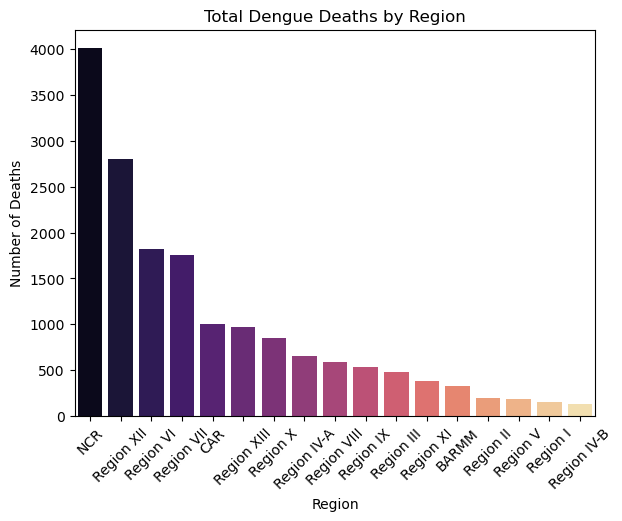

In [7]:
deaths_by_region = den.groupby('Region')['Dengue_Deaths'].sum().sort_values(ascending=False)
sns.barplot(x=deaths_by_region.index, y=deaths_by_region.values,palette='magma')
plt.title('Total Dengue Deaths by Region')
plt.ylabel('Number of Deaths')
plt.xlabel('Region')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

<h1>Insight 2: Dengue cases are most prevalent in Region IV-A.</h1>

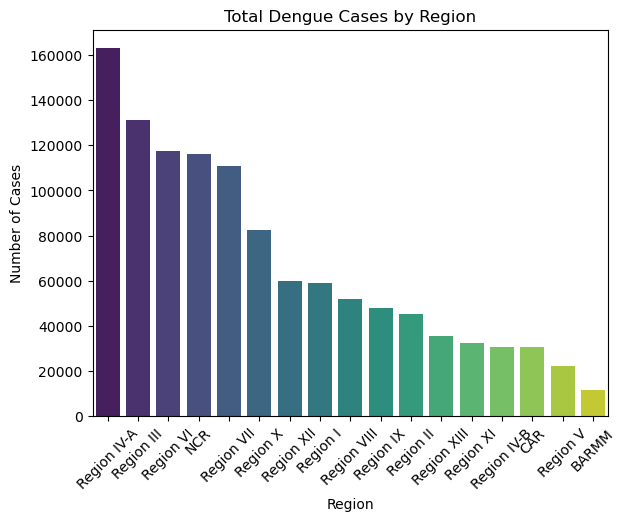

In [8]:
cases_by_region = den.groupby('Region')['Dengue_Cases'].sum().sort_values(ascending=False)
sns.barplot(x=cases_by_region.index, y=cases_by_region.values,palette='viridis')
plt.title('Total Dengue Cases by Region')
plt.ylabel('Number of Cases')
plt.xlabel('Region')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

<h1>Insight No.3: Deaths from Dengue Throughout Time in Region IV-A</h1>

In [9]:
den_IVa = den[den['Region'] == 'Region IV-A']

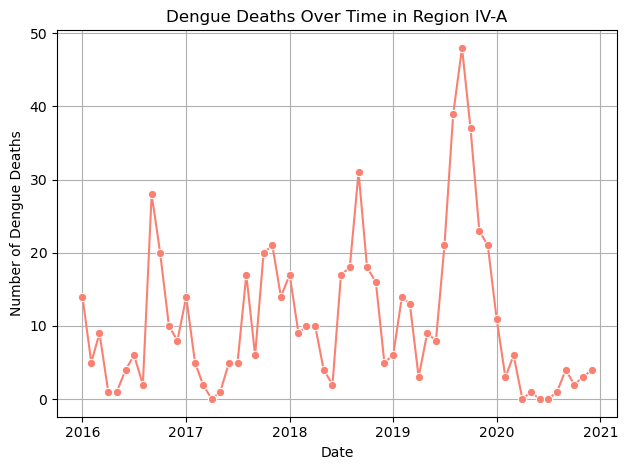

In [10]:
sns.lineplot(data=den_IVa, x='Date',y='Dengue_Deaths', marker='o', color='salmon')
plt.title('Dengue Deaths Over Time in Region IV-A')
plt.ylabel('Number of Dengue Deaths')
plt.xlabel('Date')
plt.grid(True)
plt.tight_layout()
plt.show()

<h1>Insight No.4: Dengue Case Distribution by Month in Region IV-A</h1>

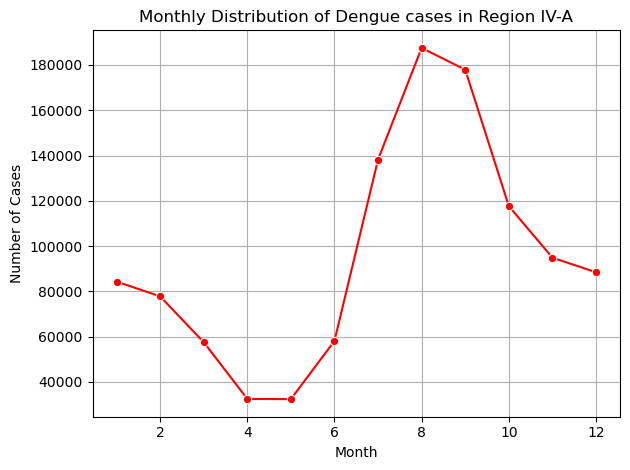

In [11]:
monthly_cases = den.groupby('Month')['Dengue_Cases'].sum()
sns.lineplot(x=monthly_cases.index, y=monthly_cases.values, marker='o', color='red')
plt.title('Monthly Distribution of Dengue cases in Region IV-A')
plt.ylabel('Number of Cases')
plt.xlabel('Month')
plt.grid(True)
plt.tight_layout()
plt.show()

<h1>Insight No.5: Certain regions exhibit regular seasonal peaks in specific months</h1>

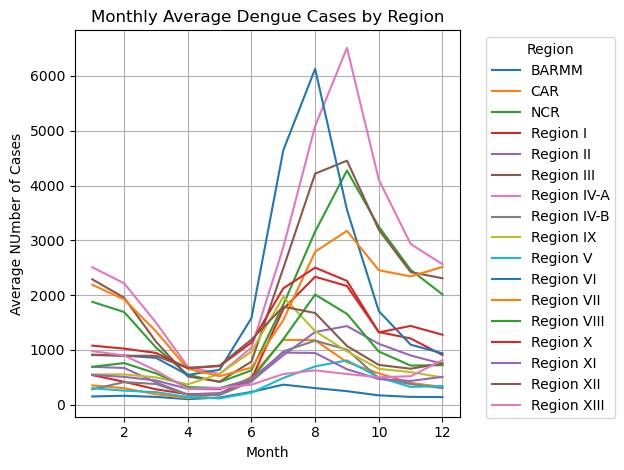

In [12]:
monthly_avg_cases = den.groupby(['Month', 'Region'])['Dengue_Cases'].mean().reset_index()
pivot_table = monthly_avg_cases.pivot(index='Month',columns='Region',values='Dengue_Cases')
pivot_table.plot(kind='line')
plt.title('Monthly Average Dengue Cases by Region')
plt.ylabel('Average NUmber of Cases')
plt.xlabel('Month')
plt.tight_layout(rect=[0,0,0.75,1])
plt.grid(True)
plt.legend(title='Region',bbox_to_anchor=(1.05,1),loc='upper left')
plt.show()

<h1>Insight No.6: Dengue cases in Region IV-A have significantly increased in 2019 when compared to previous years</h1>

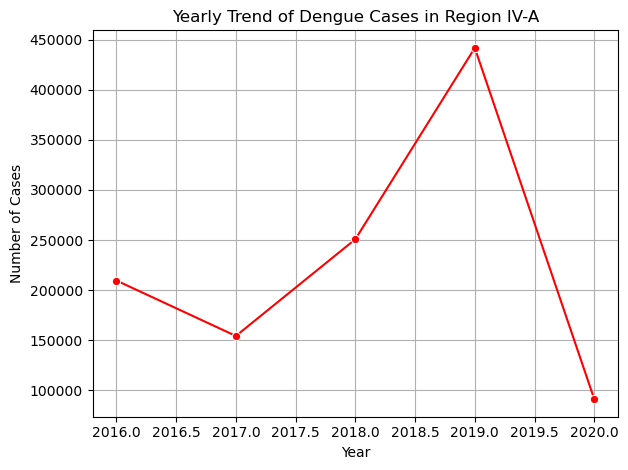

In [13]:
Yearly_cases = den.groupby('Year')['Dengue_Cases'].sum()
sns.lineplot(x=Yearly_cases.index, y=Yearly_cases.values, marker='o', color='red')
plt.title('Yearly Trend of Dengue Cases in Region IV-A')
plt.ylabel('Number of Cases')
plt.xlabel('Year')
plt.grid(True)
plt.tight_layout()
plt.show()

<h1>Insight No.7: There were comparatively many dengue-related deaths in Region IV-A in 2017 and 2019.</h1>

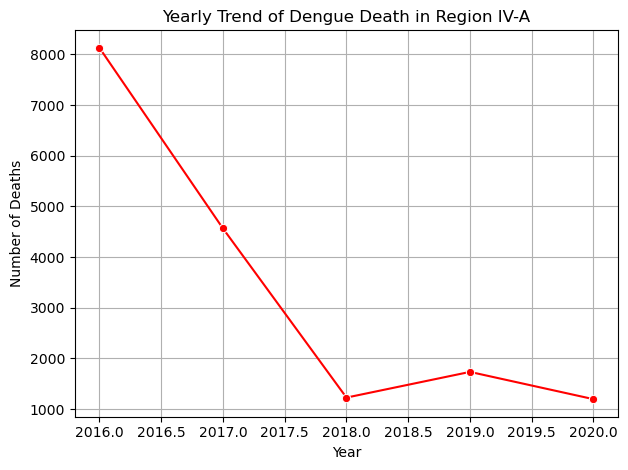

In [14]:
Yearly_deaths = den.groupby('Year')['Dengue_Deaths'].sum()
sns.lineplot(x=Yearly_deaths.index, y=Yearly_deaths.values, marker='o', color='red')
plt.title('Yearly Trend of Dengue Death in Region IV-A')
plt.ylabel('Number of Deaths')
plt.xlabel('Year')
plt.grid(True)
plt.tight_layout()
plt.show()

<h1>Insight No.8: In Region IV-A, dengue cases are most common in Q3</h1>

In [15]:
def assign_quarter(month):
    if 1<= month <= 3:
        return 'Q1'
    elif 4<= month <=6:
        return 'Q2'
    elif 7<= month <=9:
        return 'Q3'
    else:
        return 'Q4'


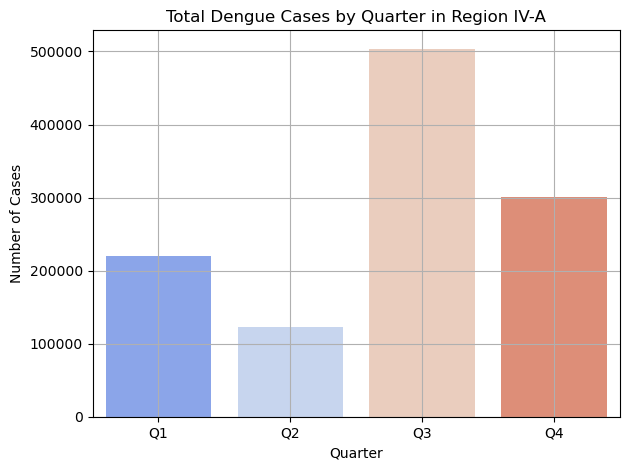

In [16]:
den['Quarter'] = den['Month'].apply(assign_quarter)
quarterly_cases = den.groupby('Quarter')['Dengue_Cases'].sum().sort_index()
sns.barplot(x=quarterly_cases.index, y=quarterly_cases.values, palette='coolwarm' )
plt.title('Total Dengue Cases by Quarter in Region IV-A')
plt.ylabel('Number of Cases')
plt.xlabel('Quarter')
plt.grid(True)
plt.tight_layout()
plt.show()

<h1>Insight No. 9: Additionally, deaths in Region IV-A typically occur in the latter months</h1>

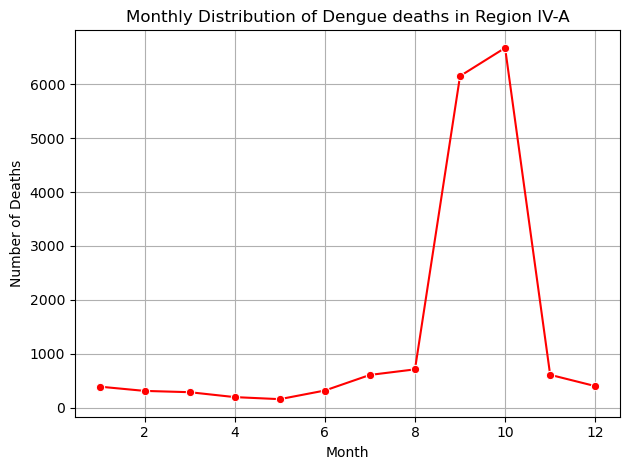

In [17]:
monthly_deaths = den.groupby('Month')['Dengue_Deaths'].sum()
sns.lineplot(x=monthly_deaths.index, y=monthly_deaths.values, marker='o', color='red')
plt.title('Monthly Distribution of Dengue deaths in Region IV-A')
plt.ylabel('Number of Deaths')
plt.xlabel('Month')
plt.grid(True)
plt.tight_layout()
plt.show()

<h1>Insight No.10: In Region IV-A, the third quarter has the highest number of deaths from deangue </h1>

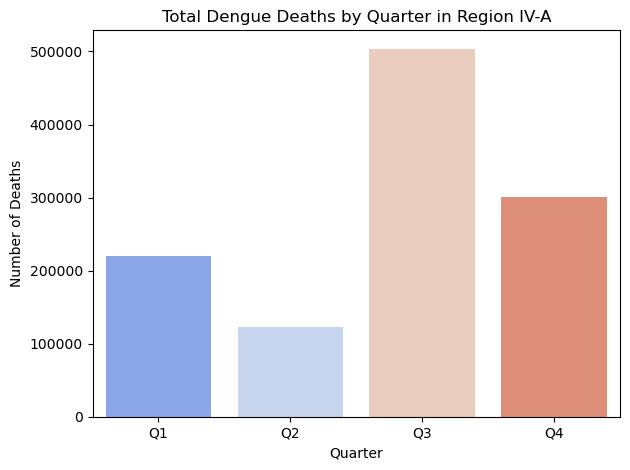

In [18]:
quarterly_deaths = den.groupby('Quarter')['Dengue_Cases'].sum().sort_index()
sns.barplot(x=quarterly_deaths.index, y=quarterly_deaths.values, palette='coolwarm' )
plt.title('Total Dengue Deaths by Quarter in Region IV-A')
plt.ylabel('Number of Deaths')
plt.xlabel('Quarter')
#plt.grid(True)
plt.tight_layout()
plt.show()

<h1>Insight No. 11: Quarterly and Annual Case Distribution</h1>

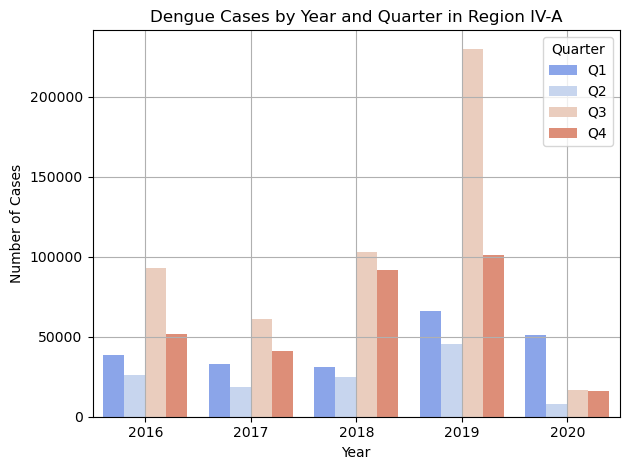

In [19]:
yearly_quarterly_cases = den.groupby(['Year','Quarter'])['Dengue_Cases'].sum().reset_index()
sns.barplot(x='Year', y='Dengue_Cases', hue='Quarter',data=yearly_quarterly_cases, palette='coolwarm' )
plt.title('Dengue Cases by Year and Quarter in Region IV-A')
plt.ylabel('Number of Cases')
plt.xlabel('Year')
plt.grid(True)
plt.tight_layout()
plt.show()

<h1>Insight No.12: Yearly and Quarterly distribution of deaths </h1>

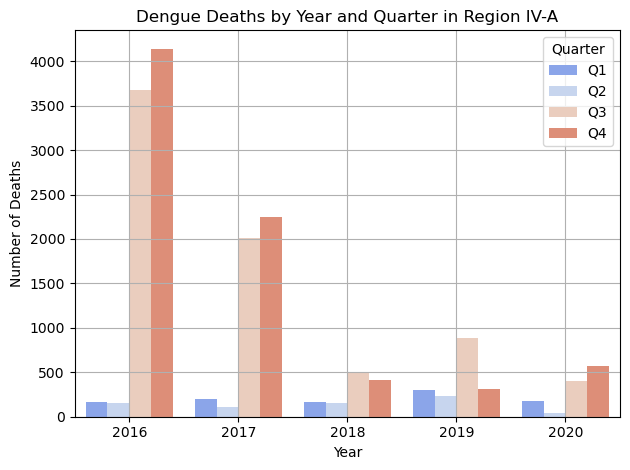

In [20]:
yearly_quarterly_deaths = den.groupby(['Year','Quarter'])['Dengue_Deaths'].sum().reset_index()
sns.barplot(x='Year', y='Dengue_Deaths', hue='Quarter',data=yearly_quarterly_deaths, palette='coolwarm' )
plt.title('Dengue Deaths by Year and Quarter in Region IV-A')
plt.ylabel('Number of Deaths')
plt.xlabel('Year')
plt.grid(True)
plt.tight_layout()
plt.show()

<h1>Insight No.13: Highlights which months have higher ratios in comparison to case number</h1>

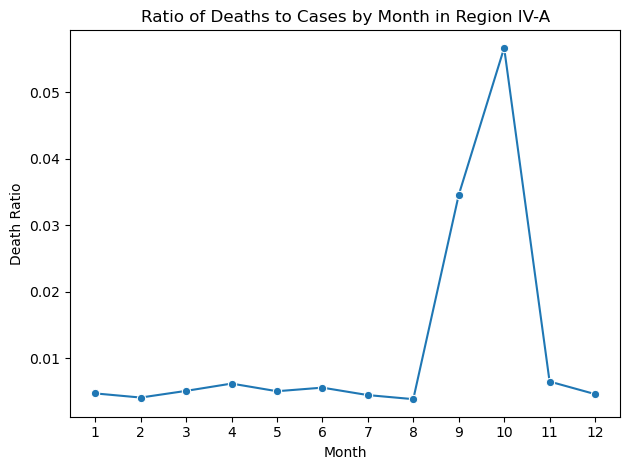

In [21]:
monthly_data = den.groupby('Month')[['Dengue_Cases','Dengue_Deaths']].sum()
monthly_data['Death_Ratio'] = monthly_data['Dengue_Deaths'] / monthly_data['Dengue_Cases']
sns.lineplot(data=monthly_data, x=monthly_data.index, y='Death_Ratio', marker='o')
plt.title('Ratio of Deaths to Cases by Month in Region IV-A')
plt.xlabel('Month')
plt.ylabel('Death Ratio')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

<h1>Insight No.14: Show smoothed trends, reducing noise for better visualization </h1>

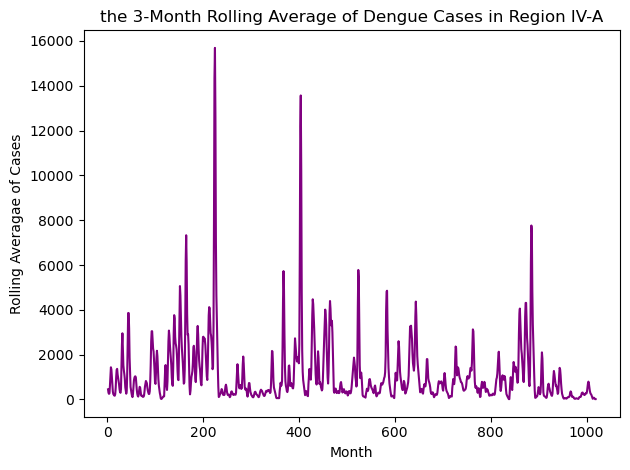

In [22]:
cases_rolling_avg = den['Dengue_Cases'].rolling(window=3).mean()
sns.lineplot(data=cases_rolling_avg, color='Purple')
plt.title('the 3-Month Rolling Average of Dengue Cases in Region IV-A')
plt.ylabel('Rolling Averagae of Cases')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

<h1>Insight No.15</h1>
<h1>What is the distribution of dengue cases in Region IV-A across the months?</h1>
<h2>The box plot reveals the distribution of dengue cases in Region IV-A across the months. It shows significant variability in the number of cases, with some months exhibiting a higher concentration of cases (especially around the middle of the year). There are outliers in several months, indicating instances where the number of cases significantly exceeded the typical range. The median for the months indicates the middle value of dengue cases, with most months showing values between 0 to 5,000 cases, while certain months (like August and September) have noticeably higher cases.<h2>

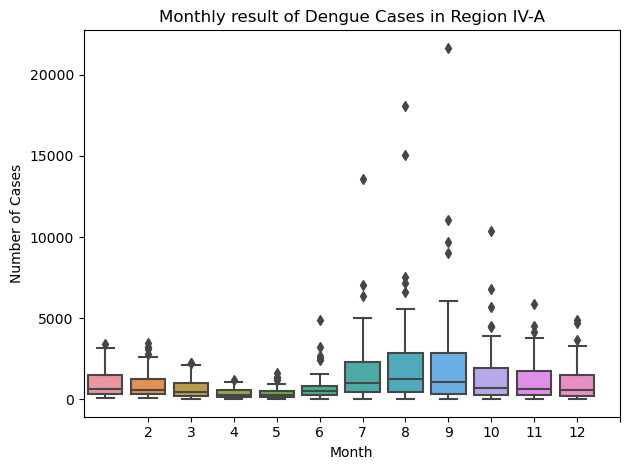

In [26]:
sns.boxplot(x=den['Month'], y=den['Dengue_Cases'])
plt.title('Monthly result of Dengue Cases in Region IV-A')
plt.ylabel('Number of Cases')
plt.xlabel('Month')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

<h1>Insight No.16</h1>
<h2>Number of Dengue Cases vs Deaths: There is a significant difference between the number of dengue cases and deaths, with cases being much higher than deaths.<h2>

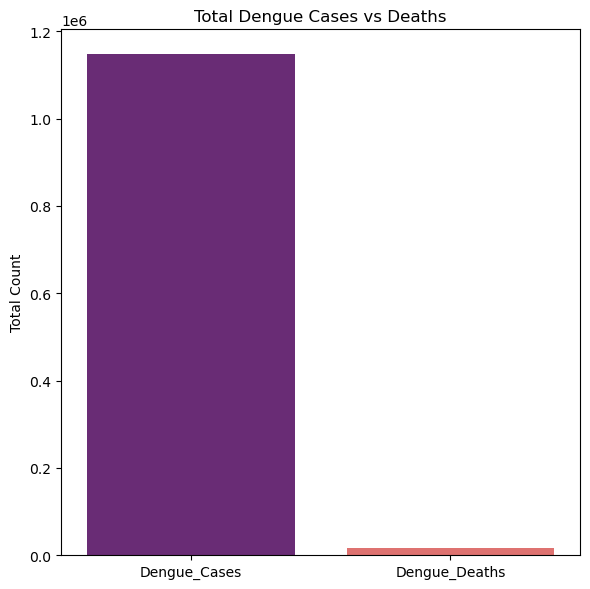

In [31]:
cases_vs_deaths = den[['Dengue_Cases', 'Dengue_Deaths']].sum()
plt.figure(figsize=(6, 6))
sns.barplot(x=cases_vs_deaths.index, y=cases_vs_deaths.values, palette='magma')
plt.title('Total Dengue Cases vs Deaths')
plt.ylabel('Total Count')
plt.tight_layout()
plt.show()

<h1>Insight No.17</h1>
<h2>Number of Dengue Deaths by Month: October and September saw the highest number of dengue-related deaths.<h2>

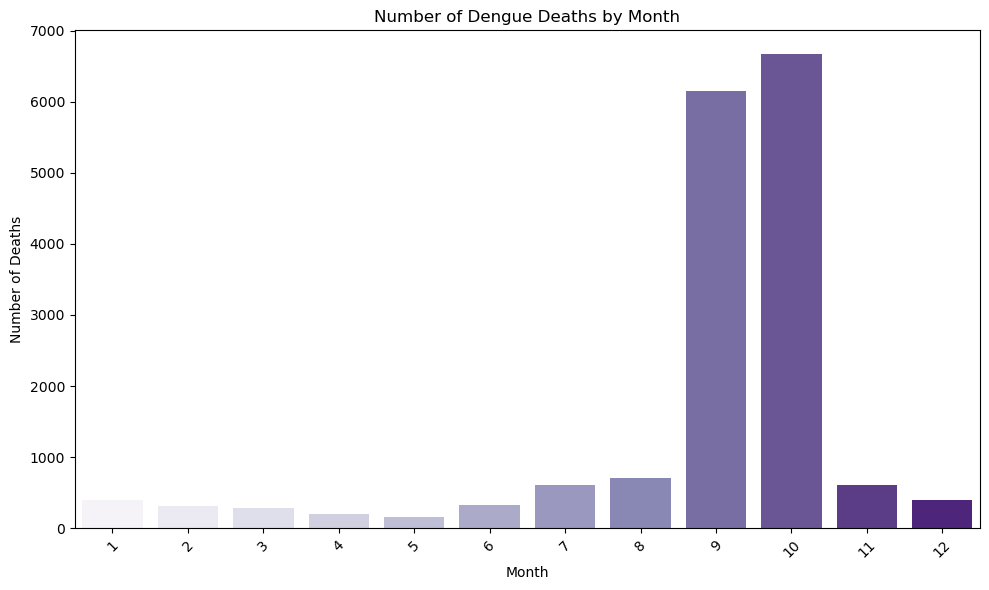

In [32]:
deaths_by_month = den.groupby('Month')['Dengue_Deaths'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=deaths_by_month.index, y=deaths_by_month.values, palette='Purples')
plt.title('Number of Dengue Deaths by Month')
plt.xlabel('Month')
plt.ylabel('Number of Deaths')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<h1>Insight No.18</h1>
<h2>Yearly Dengue Deaths by Region: The number of deaths has fluctuated over the years, peaking in 2016, with a noticeable decline in the following years.<h2>

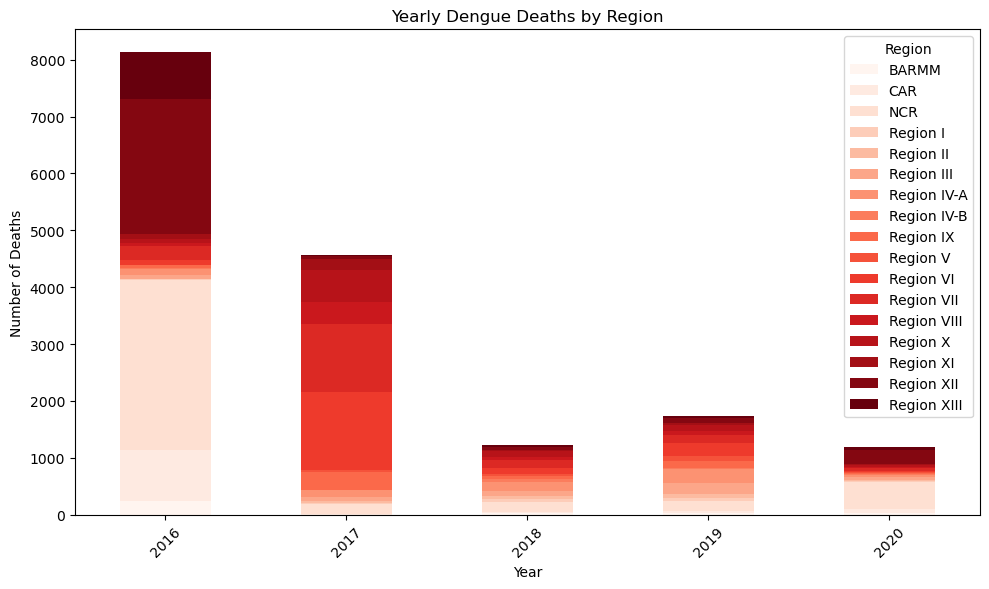

In [33]:
yearly_deaths_by_region = den.groupby(['Year', 'Region'])['Dengue_Deaths'].sum().unstack()
yearly_deaths_by_region.plot(kind='bar', figsize=(10, 6), stacked=True, colormap='Reds')
plt.title('Yearly Dengue Deaths by Region')
plt.xlabel('Year')
plt.ylabel('Number of Deaths')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<h1>Insight No.19</h1>
<h2>Yearly Dengue Cases by Region: Dengue cases have increased significantly from 2016 to 2019, with some regions showing a noticeable rise.<h2>

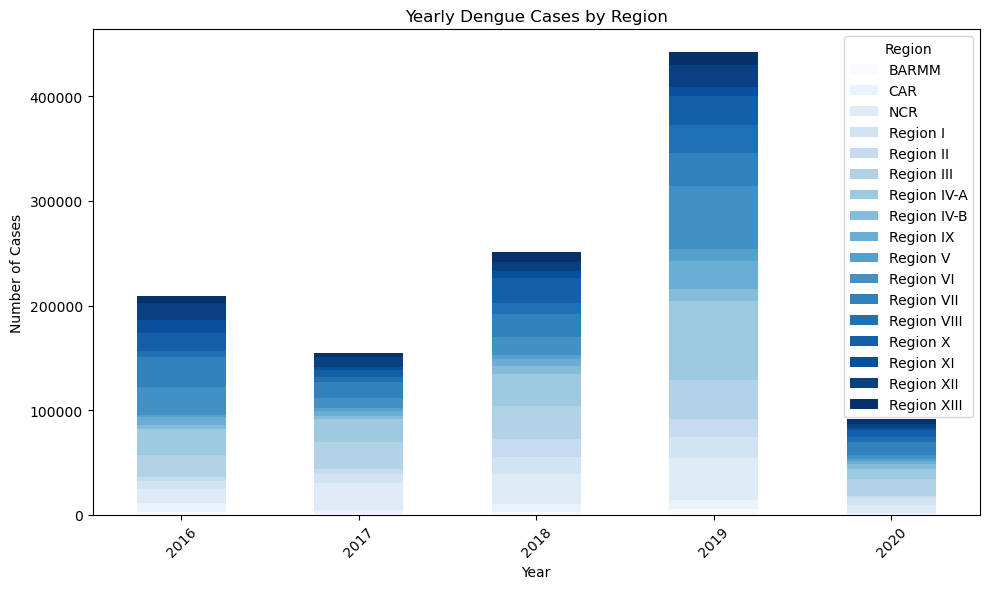

In [34]:
yearly_cases_by_region = den.groupby(['Year', 'Region'])['Dengue_Cases'].sum().unstack()
yearly_cases_by_region.plot(kind='bar', figsize=(10, 6), stacked=True, colormap='Blues')
plt.title('Yearly Dengue Cases by Region')
plt.xlabel('Year')
plt.ylabel('Number of Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<h1>Insight No.20</h1>
<h2>Comparison of Dengue Cases and Deaths by Region: The chart compares dengue cases and deaths by region, highlighting the regions with the highest cases and the deaths.<h2>

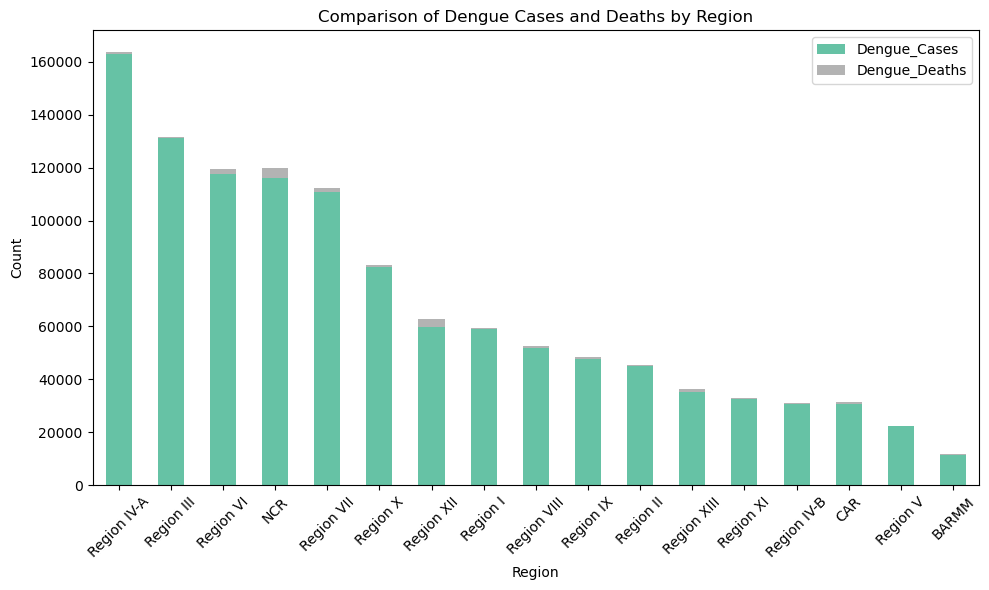

In [35]:
region_comparison = den.groupby('Region')[['Dengue_Cases', 'Dengue_Deaths']].sum()
region_comparison = region_comparison.sort_values(by='Dengue_Cases', ascending=False)
region_comparison.plot(kind='bar', figsize=(10, 6), stacked=True, colormap='Set2')
plt.title('Comparison of Dengue Cases and Deaths by Region')
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()